# S2 Demo — Supervised Learning with XGBoost (Topic 2.1)
Trains on **exactly the file Session 1 saved** (`data/processed/telco_clean`).
Local first; the optional SageMaker training-job cell is at the end.

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
while not (p / 'src').exists():
    p = p.parent
sys.path.insert(0, str(p / 'src')); REPO = p
import warnings; warnings.filterwarnings('ignore')

In [2]:
from course_utils import data, viz, models
df = data.load_processed('telco_clean')
X, y = data.prep_features(df)
S = data.make_splits(X, y)
print({k: v.shape for k, v in S.items() if hasattr(v, 'shape')})
print('churn rate train/val:', S['y_train'].mean().round(3), S['y_val'].mean().round(3))

{'X_train': (4922, 30), 'y_train': (4922,), 'X_val': (1055, 30), 'y_val': (1055,), 'X_test': (1055, 30), 'y_test': (1055,)}
churn rate train/val: 0.266 0.266


## Train a sensible baseline

In [6]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                      eval_metric='auc', random_state=42)
model.fit(S['X_train'], S['y_train'])
val_prob = model.predict_proba(S['X_val'])[:, 1]
m = viz.metric_report(S['y_val'], val_prob, name='XGBoost d=4 (validation)')

--- XGBoost d=4 (validation) ---
  accuracy: 0.797
 precision: 0.649
    recall: 0.520
        f1: 0.577
   auc_roc: 0.842


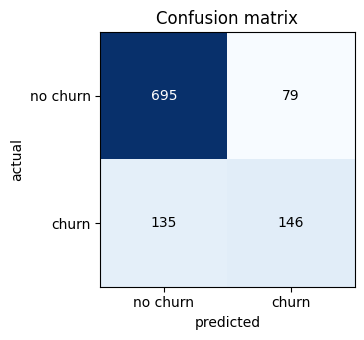

array([[695,  79],
       [135, 146]])

In [7]:
viz.plot_confusion(S['y_val'], val_prob)

**Discussion:** we catch ~half of churners — good? Depends on retention economics. Metrics are business decisions.

## Overfit on purpose — watch validation fall

           train_auc  val_auc
max_depth                    
2              0.871    0.850
4              0.921    0.842
8              0.993    0.833
12             0.999    0.823


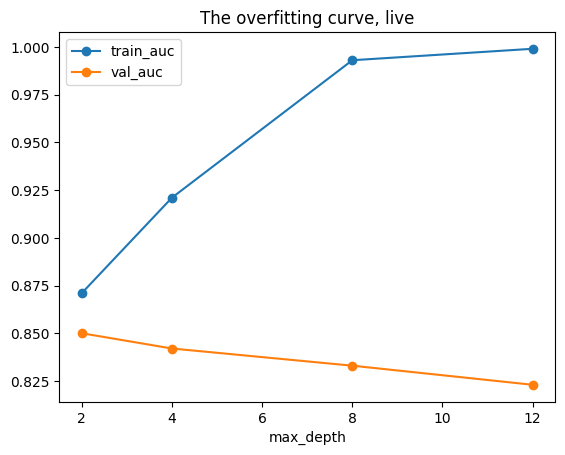

In [8]:
import pandas as pd
rows = []
for depth in [2, 4, 8, 12]:
    mdl = XGBClassifier(n_estimators=200, max_depth=depth, learning_rate=0.1,
                        eval_metric='auc', random_state=42).fit(S['X_train'], S['y_train'])
    from sklearn.metrics import roc_auc_score
    rows.append({'max_depth': depth,
                 'train_auc': roc_auc_score(S['y_train'], mdl.predict_proba(S['X_train'])[:, 1]),
                 'val_auc': roc_auc_score(S['y_val'], mdl.predict_proba(S['X_val'])[:, 1])})
curve = pd.DataFrame(rows).set_index('max_depth').round(3)
print(curve)
curve.plot(marker='o', title='The overfitting curve, live');

## Save the artifact — Session 4 deploys this exact file

In [9]:
models.save_model(model, 'churn_xgb_v1', metrics=m)

saved -> /Users/dshalvardjiev/claude-cowork/ml-course-syllabus/code-repo/models/churn_xgb_v1.joblib


PosixPath('/Users/dshalvardjiev/claude-cowork/ml-course-syllabus/code-repo/models/churn_xgb_v1.joblib')

## Optional — the same training as a SageMaker training job
Shows the managed path: containerized training, S3 in/out, tracked in SageMaker (run in Studio, needs quota).
```python
import sagemaker
from sagemaker.xgboost import XGBoost
sess = sagemaker.Session()
est = XGBoost(entry_point='train.py', framework_version='1.7-1', role=sagemaker.get_execution_role(),
              instance_count=1, instance_type='ml.m5.large',
              hyperparameters={'max_depth': 4, 'n_estimators': 200})
# est.fit({'train': 's3://<bucket>/mlcourse/train.csv'})   # ~4 min — pre-run before class
```
In class: open the **console** → SageMaker → Training jobs → walk the config of the pre-run job.